# Hồi quy tuyến tính trên tập dữ liệu Boston Housing

Dữ liệu này ban đầu là một phần của UCI Machine Learning Repository và hiện đã bị gỡ bỏ. Dữ liệu này cũng được đóng gói sẵn trong thư viện scikit-learn.
Có 506 mẫu và 13 biến đặc trưng (feature) trong tập dữ liệu này. Mục tiêu là dự đoán giá nhà dựa trên các đặc trưng đã cho.

Mô tả của tất cả các đặc trưng được liệt kê dưới đây:

  **CRIM**: Tỷ lệ tội phạm bình quân đầu người theo từng thị trấn

  **ZN**: Tỷ lệ đất ở được quy hoạch cho các lô đất trên 25.000 sq. ft (feet vuông)

  **INDUS**: Tỷ lệ diện tích đất kinh doanh phi bán lẻ (mẫu Anh) trên mỗi thị trấn

  **CHAS**: Biến giả sông Charles (= 1 nếu khu đất giáp sông; ngược lại = 0)

  **NOX**: Nồng độ oxit nitric (phần trên 10 triệu)

  **RM**: Số phòng trung bình mỗi căn nhà

  **AGE**: Tỷ lệ căn nhà do chủ sở hữu ở, được xây trước năm 1940

  **DIS**: Khoảng cách có trọng số đến năm trung tâm việc làm của Boston

  **RAD**: Chỉ số khả năng tiếp cận các đường cao tốc hướng tâm

  **TAX**: Thuế bất động sản theo giá trị đầy đủ trên mỗi $10.000

  **B**: 1000(Bk - 0,63)², trong đó Bk là tỷ lệ [người gốc Phi] theo từng thị trấn

  **LSTAT**: Tỷ lệ phần trăm dân số có địa vị thấp

  **MEDV**: Giá trị trung vị của nhà do chủ sở hữu ở, tính theo đơn vị $1000



**Import các thư viện cần thiết**

In [1]:
import numpy as np
import matplotlib.pyplot as plt 

import pandas as pd  
import seaborn as sns 

%matplotlib inline

**Tải tập dữ liệu Boston Housing từ scikit-learn**

In [ ]:
from sklearn.datasets import load_boston

boston_dataset = load_boston()

# boston_dataset là một dictionary (từ điển)
# hãy kiểm tra xem nó chứa gì
boston_dataset.keys()

**Nạp dữ liệu vào pandas dataframe**

In [3]:
boston = pd.DataFrame(boston_dataset.data, columns=boston_dataset.feature_names)
boston.head()
# temp = pd.DataFrame(boston_dataset.data, columns=boston_dataset.feature_names)
# print(temp)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33


**Giá trị mục tiêu (target) bị thiếu trong dữ liệu. Tạo một cột giá trị mục tiêu mới và thêm vào dataframe**

In [4]:
boston['MEDV'] = boston_dataset.target

**Tiền xử lý dữ liệu**

In [ ]:
# kiểm tra giá trị thiếu (missing) trong tất cả các cột
boston.isnull().sum()

**Trực quan hóa dữ liệu**

In [ ]:
# thiết lập kích thước của hình vẽ
sns.set(rc={'figure.figsize':(10,8.27)})

# vẽ biểu đồ histogram thể hiện phân phối của giá trị mục tiêu
sns.distplot(boston['MEDV'], bins=50)
plt.show()

**Ma trận tương quan**

In [ ]:
# tính tương quan cặp đôi cho tất cả các cột
correlation_matrix = boston.corr().round(2)

In [ ]:
# sử dụng hàm heatmap của seaborn để vẽ ma trận tương quan
# annot = True để in giá trị bên trong mỗi ô vuông
sns.heatmap(data=correlation_matrix, annot=True)

**Nhận xét**




*   Từ biểu đồ tương quan phía trên ta thấy **MEDV** có tương quan mạnh với **LSTAT**, **RM**



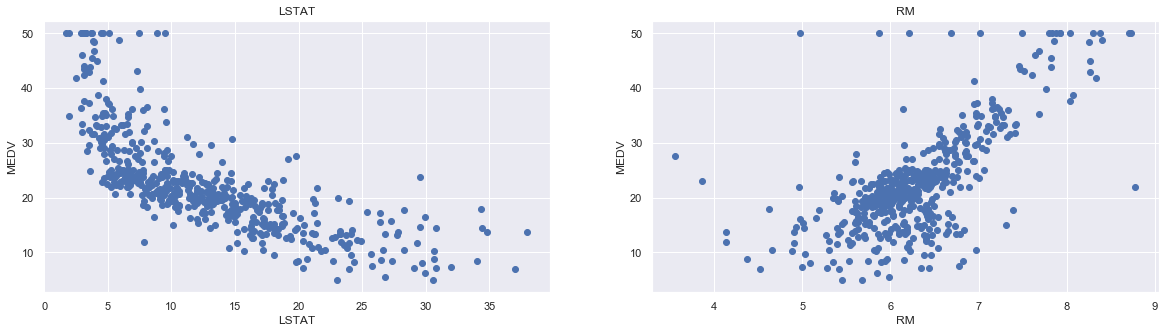

In [9]:
plt.figure(figsize=(20, 5))

features = ['LSTAT', 'RM']
target = boston['MEDV']

for i, col in enumerate(features):
    plt.subplot(1, len(features) , i+1)
    x = boston[col]
    y = target
    plt.scatter(x, y, marker='o')
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel('MEDV')

**Chuẩn bị dữ liệu để huấn luyện**

In [10]:
X = pd.DataFrame(np.c_[boston['LSTAT'], boston['RM']], columns = ['LSTAT','RM'])
# X = boston.loc[:, boston.columns != 'MEDV']
Y = boston['MEDV']
print("X",X)

X      LSTAT     RM
0     4.98  6.575
1     9.14  6.421
2     4.03  7.185
3     2.94  6.998
4     5.33  7.147
5     5.21  6.430
6    12.43  6.012
7    19.15  6.172
8    29.93  5.631
9    17.10  6.004
10   20.45  6.377
11   13.27  6.009
12   15.71  5.889
13    8.26  5.949
14   10.26  6.096
15    8.47  5.834
16    6.58  5.935
17   14.67  5.990
18   11.69  5.456
19   11.28  5.727
20   21.02  5.570
21   13.83  5.965
22   18.72  6.142
23   19.88  5.813
24   16.30  5.924
25   16.51  5.599
26   14.81  5.813
27   17.28  6.047
28   12.80  6.495
29   11.98  6.674
..     ...    ...
476  18.68  6.484
477  24.91  5.304
478  18.03  6.185
479  13.11  6.229
480  10.74  6.242
481   7.74  6.750
482   7.01  7.061
483  10.42  5.762
484  13.34  5.871
485  10.58  6.312
486  14.98  6.114
487  11.45  5.905
488  18.06  5.454
489  23.97  5.414
490  29.68  5.093
491  18.07  5.983
492  13.35  5.983
493  12.01  5.707
494  13.59  5.926
495  17.60  5.670
496  21.14  5.390
497  14.10  5.794
498  12.92  6.019
499  15.

**Chia dữ liệu thành tập huấn luyện và tập kiểm tra**

In [ ]:
from sklearn.model_selection import train_test_split

# chia tập huấn luyện và tập kiểm tra theo tỷ lệ 80% : 20%
# gán random_state bằng một giá trị bất kỳ để đảm bảo tính nhất quán (consistency)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state=5)
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

**Huấn luyện mô hình bằng LinearRegression của sklearn**

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

lin_model = LinearRegression()
lin_model.fit(X_train, Y_train)

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None,
         normalize=False)

In [ ]:
# đánh giá mô hình trên tập huấn luyện

y_train_predict = lin_model.predict(X_train)
rmse = (np.sqrt(mean_squared_error(Y_train, y_train_predict)))
r2 = r2_score(Y_train, y_train_predict)

print("Hiệu năng của mô hình trên tập huấn luyện")
print("--------------------------------------")
print('RMSE là {}'.format(rmse))
print('Điểm R2 là {}'.format(r2))
print("\n")

# đánh giá mô hình trên tập kiểm tra

y_test_predict = lin_model.predict(X_test)
# sai số căn bậc hai trung bình bình phương của mô hình
rmse = (np.sqrt(mean_squared_error(Y_test, y_test_predict)))

# điểm R-squared của mô hình
r2 = r2_score(Y_test, y_test_predict)

print("Hiệu năng của mô hình trên tập kiểm tra")
print("--------------------------------------")
print('RMSE là {}'.format(rmse))
print('Điểm R2 là {}'.format(r2))

In [ ]:
# vẽ biểu đồ y_test so với y_pred
# lý tưởng thì nó phải là một đường thẳng
plt.scatter(Y_test, y_test_predict, marker='o')
plt.xlabel('Y_test')
plt.ylabel('y_test_predict')
plt.show()


In [15]:
Check = np.c_[Y_test.values,y_test_predict]
print(Check)

[[37.6        37.38999403]
 [27.9        29.79290611]
 [22.6        25.86755297]
 [13.8         0.31370828]
 [35.2        33.31385559]
 [10.4         7.97136102]
 [23.9        30.7066387 ]
 [29.         27.83076842]
 [22.8        26.26693081]
 [23.2        21.97871678]
 [33.2        32.33149332]
 [19.         23.21791374]
 [20.3        22.9932889 ]
 [36.1        30.97465356]
 [24.4        27.19747687]
 [17.2        20.7171544 ]
 [17.9        -0.67524986]
 [19.6        18.01248654]
 [19.7        12.3108109 ]
 [15.         21.90615827]
 [ 8.1         4.82262227]
 [23.         24.00423026]
 [44.8        37.70279396]
 [23.1        24.59521859]
 [32.2        29.6355729 ]
 [10.8        12.5396288 ]
 [23.1        27.07081337]
 [21.2        22.44485896]
 [22.2        27.64895322]
 [24.1        28.99223597]
 [17.3        11.38689571]
 [ 7.         10.39119661]
 [12.7        18.02726641]
 [17.8        24.65916571]
 [26.4        26.3259374 ]
 [19.6        22.97547671]
 [25.1        26.32610451]
 